In [ ]:
# =========================
# 1. Imports
# =========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


# =========================
# 2. Generate Dummy Dataset
# =========================
def generate_data(num_samples=200, img_size=64):
    X = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)
    y = np.zeros((num_samples, img_size, img_size, 1), dtype=np.float32)

    for i in range(num_samples):
        radius = np.random.randint(5, 15)
        cx = np.random.randint(radius, img_size - radius)
        cy = np.random.randint(radius, img_size - radius)

        Y, X_grid = np.ogrid[:img_size, :img_size]
        dist = (X_grid - cx)**2 + (Y - cy)**2

        mask = dist <= radius**2
        y[i, mask, 0] = 1.0

        X[i, :, :, 0] = np.random.rand(img_size, img_size) * 0.3
        X[i, mask, 0] += 0.7

    return X, y

X, y = generate_data(300)

X_train, X_test = X[:250], X[250:]
y_train, y_test = y[:250], y[250:]



In [ ]:

# =========================
# 3. Dice + IoU
# =========================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# IoU Metric
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)


# =========================
# 4. Build U-Net
# =========================
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def build_unet(input_shape=(64, 64, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 16)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 32)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = conv_block(p2, 64)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = conv_block(u1, 32)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = conv_block(u2, 16)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    model = models.Model(inputs, outputs)
    return model


model = build_unet()

model.compile(
    optimizer="adam",
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

model.summary()



In [2]:

# =========================
# 5. Train
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=8
)

Epoch 1/5
32/32 [==============================] - 2s 54ms/step - loss: 0.0272 - dice_coefficient: 0.9797 - iou_metric: 0.9647 - val_loss: 0.0394 - val_dice_coefficient: 0.9741 - val_iou_metric: 0.9520
Epoch 2/5
32/32 [==============================] - 2s 49ms/step - loss: 0.0245 - dice_coefficient: 0.9816 - iou_metric: 0.9708 - val_loss: 0.0193 - val_dice_coefficient: 0.9848 - val_iou_metric: 0.9785
Epoch 3/5
32/32 [==============================] - 2s 49ms/step - loss: 0.0175 - dice_coefficient: 0.9864 - iou_metric: 0.9795 - val_loss: 0.0157 - val_dice_coefficient: 0.9883 - val_iou_metric: 0.9825
Epoch 4/5
32/32 [==============================] - 2s 52ms/step - loss: 0.0200 - dice_coefficient: 0.9853 - iou_metric: 0.9753 - val_loss: 0.0265 - val_dice_coefficient: 0.9795 - val_iou_metric: 0.9651
Epoch 5/5
32/32 [==============================] - 2s 50ms/step - loss: 0.0164 - dice_coefficient: 0.9872 - iou_metric: 0.9803 - val_loss: 0.0188 - val_dice_coefficient: 0.9867 - val_iou_metri

1/1 [==============================] - 0s 55ms/step


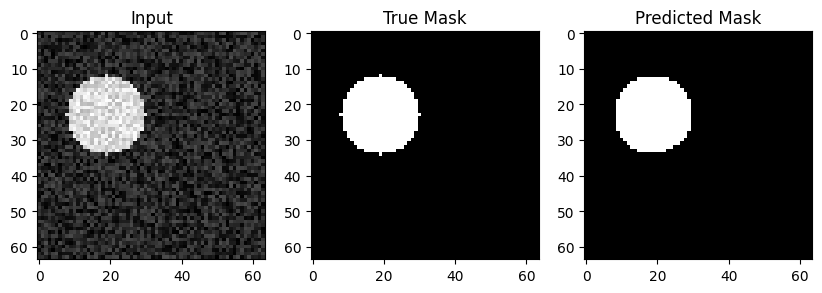

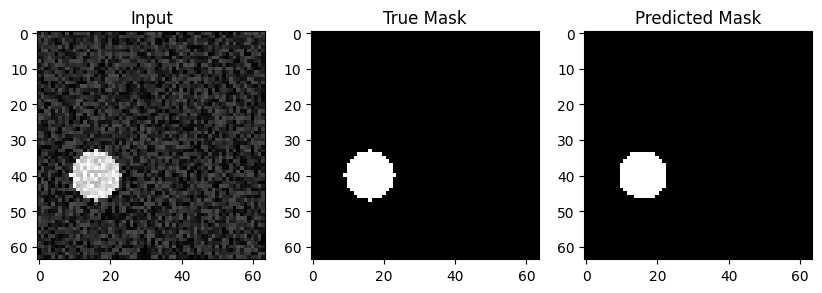

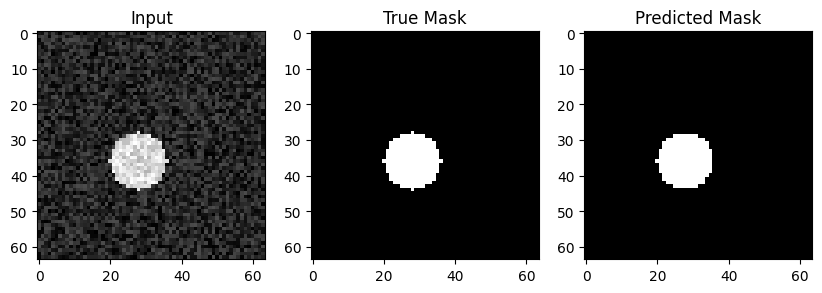

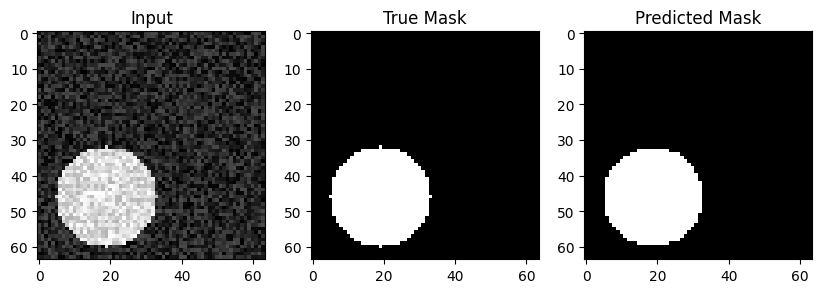

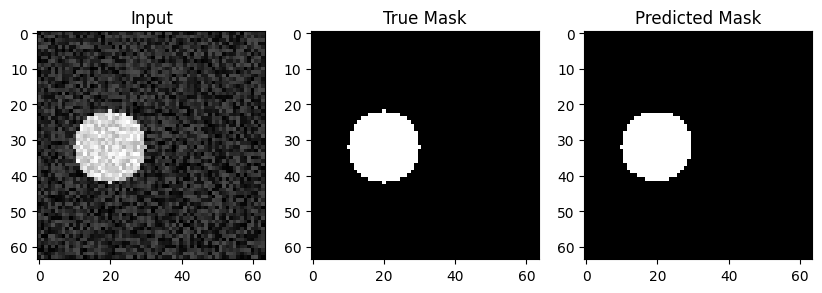

In [3]:
# =========================
# 6. Predict & Visualize
# =========================
preds = model.predict(X_test[:5])

def show_results(X, y_true, y_pred, n=5):
    for i in range(n):
        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Input")
        plt.imshow(X[i].squeeze(), cmap="gray")

        plt.subplot(1,3,2)
        plt.title("True Mask")
        plt.imshow(y_true[i].squeeze(), cmap="gray")

        plt.subplot(1,3,3)
        plt.title("Predicted Mask")
        plt.imshow(y_pred[i].squeeze() > 0.5, cmap="gray")

        plt.show()

show_results(X_test, y_test, preds)
